#  Exploratory Data Analysis

## Most Sold Products

This analysis identifies the products with the highest sales volume based on the quantity sold.

In [ ]:
import pandas as pd
import sys
sys.path.append("..")
from cleaning import clean
# Load the csv file 

df=pd.read_csv('../DATA/raw/dirty_cafe_sales.csv')
df=clean(df)


  Transaction ID    Item  Quantity  Price Per Unit  Total Spent  \
0    txn_1961373  coffee       2.0             2.0          4.0   
1    txn_4977031    cake       4.0             3.0         12.0   
2    txn_4271903  cookie       4.0             1.0          4.0   
3    txn_7034554   salad       2.0             5.0         10.0   
4    txn_3160411  coffee       2.0             2.0          4.0   

   Payment Method  Location Transaction Date  
0     credit card  takeaway       2023-09-08  
1            cash  in-store       2023-05-16  
2     credit card  in-store       2023-07-19  
3             NaN       NaN       2023-04-27  
4  digital wallet  in-store       2023-06-11  


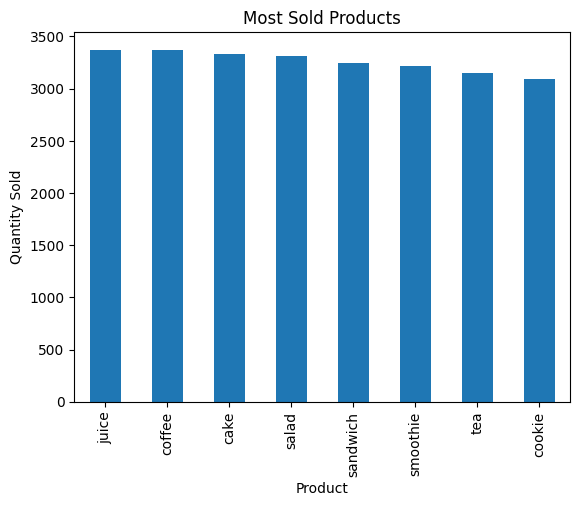

In [7]:
import matplotlib.pyplot as plt
top_products = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind="bar")

plt.title("Most Sold Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

### juice and coffe are the most sold products.

## Revenue per product

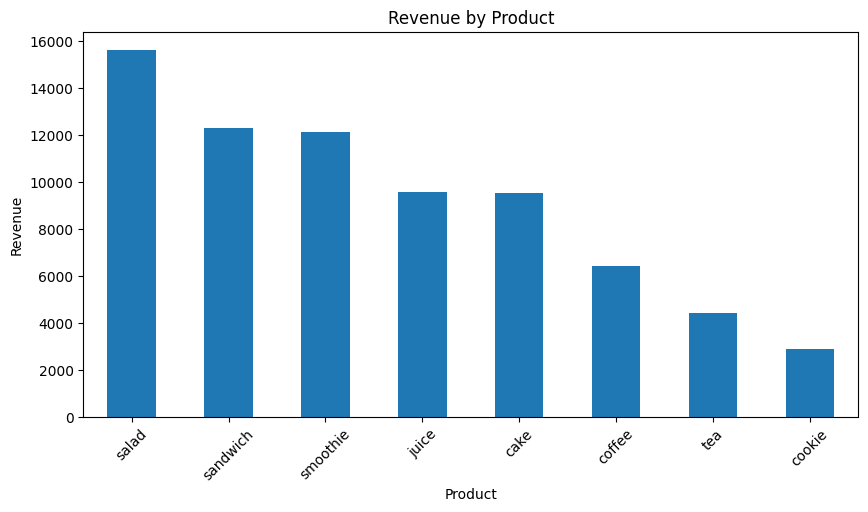

In [13]:
revenue = (
    df.groupby("Item")["Total Spent"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### insight: salad is what give more revonue.

## sales over time

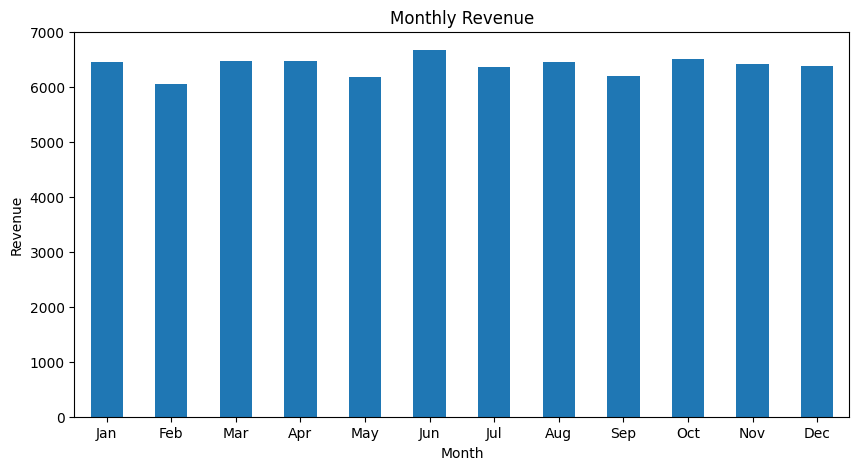

In [19]:


monthly_sales = (
    df.groupby(df["Transaction Date"].dt.month)["Total Spent"]
    .sum()
    .sort_index()
)

monthly_sales.index = [
    "Jan", "Feb", "Mar", "Apr",
    "May", "Jun", "Jul", "Aug",
    "Sep", "Oct", "Nov", "Dec"
]

plt.figure(figsize=(10,5))

monthly_sales.plot(kind="bar")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=0)

plt.show()

### insight: we can see a very consistant sales throghout the year.

## Payment methods

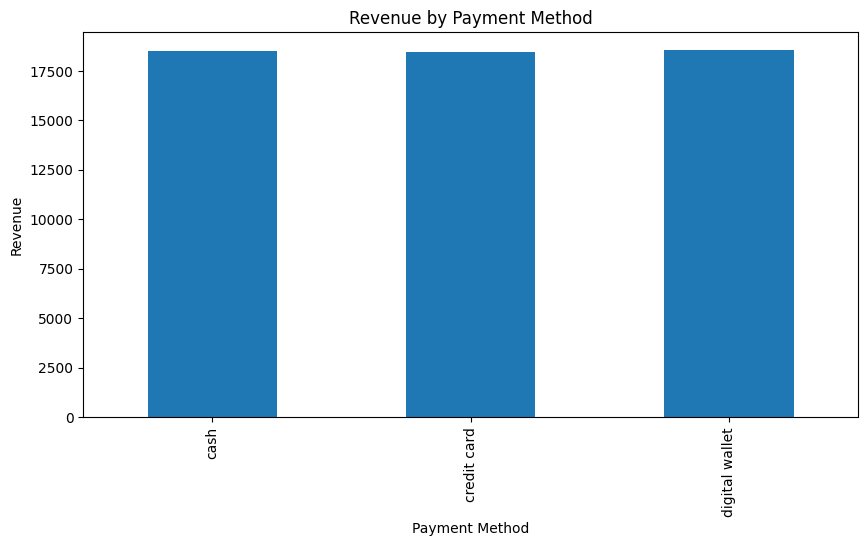

In [15]:
payment_method_sales = (
    df.groupby("Payment Method")["Total Spent"]
    .sum()
)
plt.figure(figsize=(10,5))

payment_method_sales.plot(kind="bar")

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.show()

plt.show()

### insight: there's no such difference between payment methods.
 

## Revenue by Location

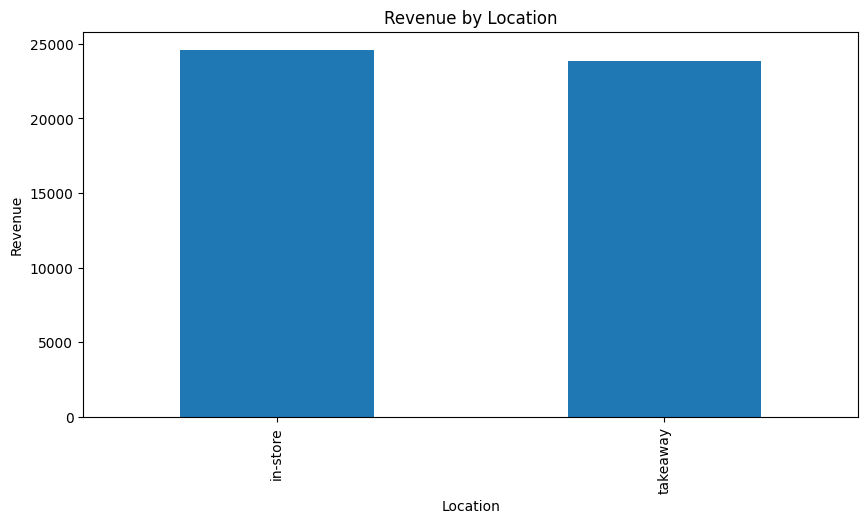

In [18]:
location_sales = (
    df.groupby("Location")["Total Spent"]
    .sum()
)
plt.figure(figsize=(10,5))

location_sales.plot(kind="bar")

plt.title("Revenue by Location")
plt.xlabel("Location")
plt.ylabel("Revenue")

plt.show()

plt.show()


### insight: in-store give more revenue.

# Final Conclusion

The analysis revealed interesting sales patterns and customer behavior throughout the dataset.

Among the products, **coffee** and **juice** were the most sold items, indicating high customer demand for beverages. However, **salad** generated the highest revenue by a significant margin, suggesting that higher-priced items can contribute more to total revenue even with lower sales volume.

Sales remained relatively stable throughout the year, with a slight increase observed in June. This indicates a consistent sales pattern with no strong seasonal fluctuations.

The analysis of payment methods showed no significant differences in customer preferences, suggesting balanced usage across all available payment options.

Regarding customer purchasing behavior, **in-store transactions generated higher sales** compared to other locations, highlighting the importance of physical store purchases for the business.

Overall, the project demonstrated the complete workflow of a real-world data analysis task, including data cleaning, validation, exploratory analysis, data visualization, and business insight extraction using Python and Pandas.